# Persistence (Naïve) Baseline Model

## Purpose
Establishes a naïve baseline forecast using the **persistence model**: the prediction for each time step is simply the value observed at the previous time step. Any candidate model must beat this baseline to demonstrate genuine predictive skill.

Walk-forward validation is used throughout to simulate real one-step-ahead forecasting conditions — the model is never given access to future observations.

## Inputs
- `data/dataset.csv` — Training dataset (93 monthly observations)

## Outputs
- The RMSE is printed inline and serves as the baseline benchmark.

In [1]:
import pandas as pd
from sklearn.metrics import mean_squared_error
from math import sqrt

## Load Training Data

Load the training series and confirm the first few rows are as expected.

In [2]:
series = pd.read_csv('data/dataset.csv', index_col=0, parse_dates=True).iloc[:, 0]
series.head()

Month
1964-01-01    2815
1964-02-01    2672
1964-03-01    2755
1964-04-01    2721
1964-05-01    2946
Name: Sales, dtype: int64

## Visual Check

Quick line plot to confirm the data loaded correctly before proceeding.

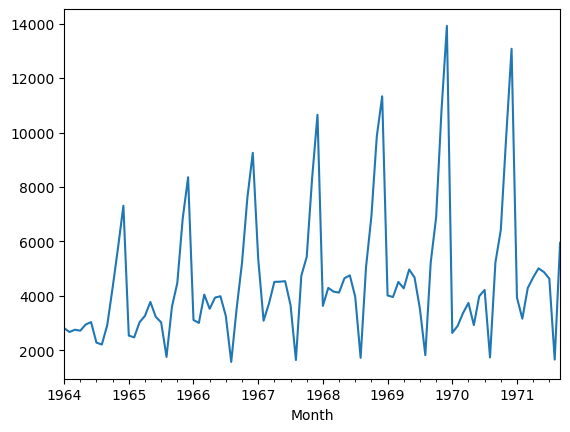

In [3]:
series.plot();

## Train / Test Split

Split the series 50/50 into train and test sets using a fixed-size in-sample split. The 50% split is deliberately conservative — it leaves a meaningful test window for evaluating walk-forward performance without starving the training set.

In [4]:
# prepare data
X = series.values
X = X.astype('float64')
train_size = int(len(X) * 0.50)
train, test = X[0:train_size], X[train_size:]

## Walk-Forward Validation

At each step the model predicts the next value as the **most recent observed value** (`history[-1]`). After predicting, the true observation is appended to history so the next prediction always uses up-to-date information. This mirrors the conditions of genuine out-of-sample forecasting.

In [5]:
# walk-forward validation
history = [x for x in train]
predictions = list()
for i in range(len(test)):
    # predict
    yhat = history[-1]
    predictions.append(yhat)
    # observation
    obs = test[i]
    history.append(obs)
    print('>Predicted=%.3f, Expected=%3.f' % (yhat, obs))

>Predicted=5428.000, Expected=8314
>Predicted=8314.000, Expected=10651
>Predicted=10651.000, Expected=3633
>Predicted=3633.000, Expected=4292
>Predicted=4292.000, Expected=4154
>Predicted=4154.000, Expected=4121
>Predicted=4121.000, Expected=4647
>Predicted=4647.000, Expected=4753
>Predicted=4753.000, Expected=3965
>Predicted=3965.000, Expected=1723
>Predicted=1723.000, Expected=5048
>Predicted=5048.000, Expected=6922
>Predicted=6922.000, Expected=9858
>Predicted=9858.000, Expected=11331
>Predicted=11331.000, Expected=4016
>Predicted=4016.000, Expected=3957
>Predicted=3957.000, Expected=4510
>Predicted=4510.000, Expected=4276
>Predicted=4276.000, Expected=4968
>Predicted=4968.000, Expected=4677
>Predicted=4677.000, Expected=3523
>Predicted=3523.000, Expected=1821
>Predicted=1821.000, Expected=5222
>Predicted=5222.000, Expected=6872
>Predicted=6872.000, Expected=10803
>Predicted=10803.000, Expected=13916
>Predicted=13916.000, Expected=2639
>Predicted=2639.000, Expected=2899
>Predicted=2

## Baseline RMSE

Compute and print the Root Mean Squared Error over all test predictions. This RMSE is the minimum bar that subsequent ARIMA models must clear to be considered useful.

In [6]:
# report performance
rmse = sqrt(mean_squared_error(test, predictions))
print('RMSE: %.3f' % rmse)

RMSE: 3186.501
